In [1]:
%matplotlib inline

import os
os.environ["KMP_DUPLICATE_LIB_OK"]="TRUE"

import torch
import requests
import numpy as np

from pathlib import Path

from torchcodec.decoders import VideoDecoder
from torchvision.utils import make_grid
from torchvision.transforms.v2.functional import to_pil_image
import matplotlib.pyplot as plt

In [2]:

def plot(frames:torch.Tensor, title:str|None=None):
    '''
    Args:
        frames (torch.Tensor): Image frames of shape (C, H, W) or (B, C, H, W)
    '''
    plt.rcParams['savefig.bbox']='tight'
    fig, ax=plt.subplots()
    ax.imshow(to_pil_image(make_grid(frames)))
    ax.set(xticklabels=[], yticklabels=[], xticks=[], yticks=[])
    if title is not None: ax.set_title(title)
    plt.tight_layout()


In [3]:
source='file'
raw_video_bytes=None

if source=='file':
    data_dirpath=Path('D:/data/kinetics')
    raw_video_bytes=data_dirpath/'_WWyCxEok2I_000078_000088.mp4'
else:
    # Video source: https://www.pexels.com/video/dog-eating-854132/
    url="https://videos.pexels.com/video-files/854132/854132-sd_640_360_25fps.mp4"
    response=requests.get(url, headers={"User-Agent":""})
    if response.status_code!=200:
        raise RuntimeError(f'Failed to download video {response.status_code=}.')
    raw_video_bytes=response.content

In [4]:
decoder=VideoDecoder(raw_video_bytes) # input can be raw (encoded) video bytes or filepath
print(decoder.metadata)

VideoStreamMetadata:
  duration_seconds_from_header: 10.01
  begin_stream_seconds_from_header: 0.0
  bit_rate: 1384681.0
  codec: h264
  stream_index: 0
  duration_seconds: 10.01
  begin_stream_seconds: 0.0
  begin_stream_seconds_from_content: 0.0
  end_stream_seconds_from_content: 10.01
  width: 480
  height: 360
  num_frames_from_header: 300
  num_frames_from_content: 300
  average_fps_from_header: 29.97003
  pixel_aspect_ratio: 0
  end_stream_seconds: 10.01
  num_frames: 300
  average_fps: 29.97003



In [5]:
first_frame=decoder[0] # using a single int index
every_twenty_frame=decoder[0:-1:20] # using slices
print(f'first frame shape {first_frame.shape=}, dtype {first_frame.dtype}')
print(f'every twenty frame shape {every_twenty_frame.shape=}, dtype {every_twenty_frame.dtype}')

first frame shape first_frame.shape=torch.Size([3, 360, 480]), dtype torch.uint8
every twenty frame shape every_twenty_frame.shape=torch.Size([15, 3, 360, 480]), dtype torch.uint8


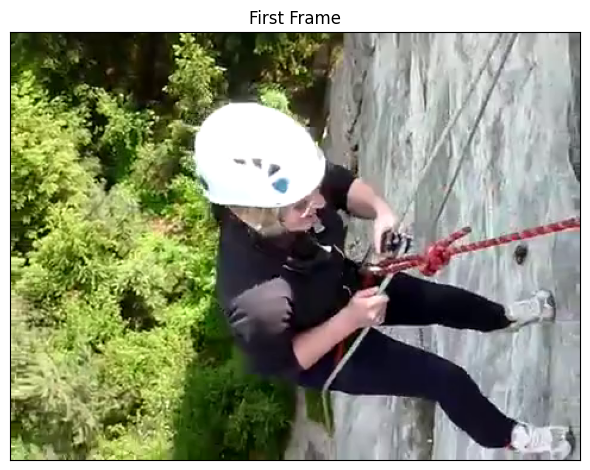

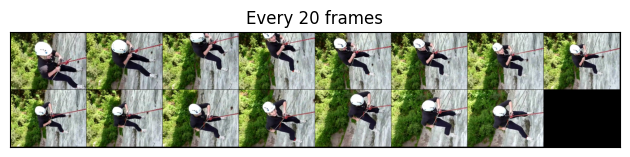

In [9]:
plot(first_frame, 'First Frame')
plot(every_twenty_frame, 'Every 20 frames')

In [10]:
for frame in decoder:
    assert (
        isinstance(frame, torch.Tensor) and frame.shape==(3, decoder.metadata.height,
                                                         decoder.metadata.width)
    )

In [11]:
last_frame=decoder.get_frame_at(len(decoder)-1)
print(f'{type(last_frame)=}')
print(last_frame)
print(last_frame.data.shape, last_frame.pts_seconds, last_frame.duration_seconds)

type(last_frame)=<class 'torchcodec._frame.Frame'>
Frame:
  data (shape): torch.Size([3, 360, 480])
  pts_seconds: 9.976633333333334
  duration_seconds: 0.03336666666666667

torch.Size([3, 360, 480]) 9.976633333333334 0.03336666666666667


In [12]:
other_frames=decoder.get_frames_at([10,0,50])
print(f'{type(other_frames)=}')
print(other_frames)

type(other_frames)=<class 'torchcodec._frame.FrameBatch'>
FrameBatch:
  data (shape): torch.Size([3, 3, 360, 480])
  pts_seconds: tensor([0.3337, 0.0000, 1.6683], dtype=torch.float64)
  duration_seconds: tensor([0.0334, 0.0334, 0.0334], dtype=torch.float64)



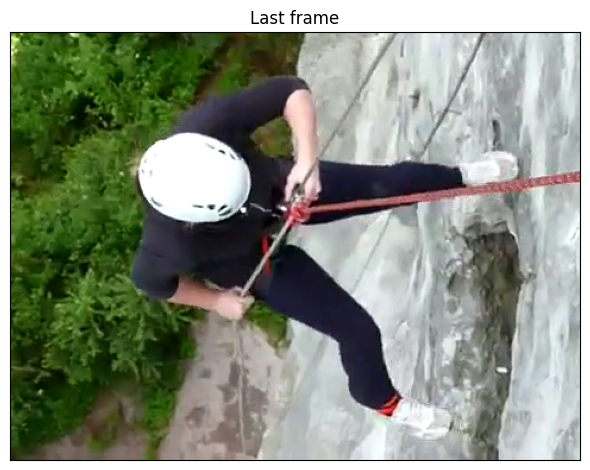

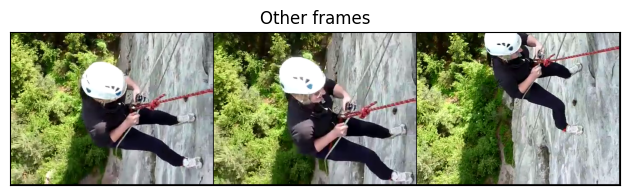

In [13]:
plot(last_frame.data, 'Last frame')
plot(other_frames.data, 'Other frames')

In [14]:
frame_at_2_seconds=decoder.get_frame_played_at(seconds=2)
print(f'{type(frame_at_2_seconds)=}')
print(frame_at_2_seconds)

type(frame_at_2_seconds)=<class 'torchcodec._frame.Frame'>
Frame:
  data (shape): torch.Size([3, 360, 480])
  pts_seconds: 1.9686333333333332
  duration_seconds: 0.03336666666666667



In [16]:
other_frames=decoder.get_frames_played_at(seconds=[10., 0.3, 5])
print(f'{type(other_frames)=}')
print(other_frames)

type(other_frames)=<class 'torchcodec._frame.FrameBatch'>
FrameBatch:
  data (shape): torch.Size([3, 3, 360, 480])
  pts_seconds: tensor([9.9766, 0.2669, 4.9716], dtype=torch.float64)
  duration_seconds: tensor([0.0334, 0.0334, 0.0334], dtype=torch.float64)



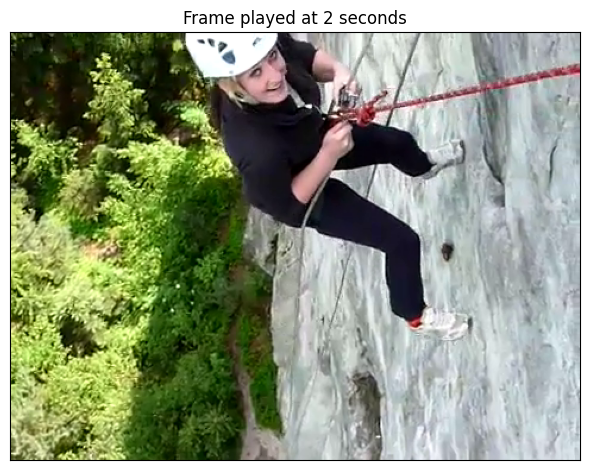

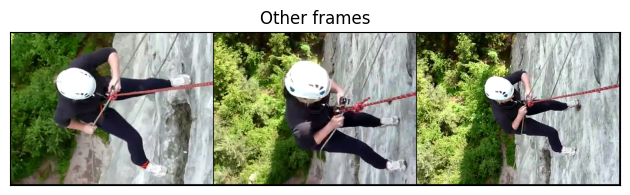

In [19]:
plot(frame_at_2_seconds.data, 'Frame played at 2 seconds')
plot(other_frames.data, 'Other frames')